In [129]:
import pandas as pd
import numpy as np
data= {
    "NAME":["AMIR", "RJ", "AK", "SAHIL", "PK" ,"SK","AYAAN","RAM", "SHAM","AWES","AM","PM","AM","AFSDFA","ASDF"],
    "MATH":[50,np.nan,200,40,45,70,40,60,79,54,34,68,90,56,34],
    "SCIENCE":[78,85,None,80,23,45,76,45,87,56,89,9,56,34,23],
    "ENGLISH":[None,80,60,40,80,67,45,34,67,34,87,45,23,45,77],
    "ATTENDANCE":[90,None,60,80,34,45,56,78,65,78,76,56,45,90,67]
}
df=pd.DataFrame(data)
print(df)

      NAME   MATH  SCIENCE  ENGLISH  ATTENDANCE
0     AMIR   50.0     78.0      NaN        90.0
1       RJ    NaN     85.0     80.0         NaN
2       AK  200.0      NaN     60.0        60.0
3    SAHIL   40.0     80.0     40.0        80.0
4       PK   45.0     23.0     80.0        34.0
5       SK   70.0     45.0     67.0        45.0
6    AYAAN   40.0     76.0     45.0        56.0
7      RAM   60.0     45.0     34.0        78.0
8     SHAM   79.0     87.0     67.0        65.0
9     AWES   54.0     56.0     34.0        78.0
10      AM   34.0     89.0     87.0        76.0
11      PM   68.0      9.0     45.0        56.0
12      AM   90.0     56.0     23.0        45.0
13  AFSDFA   56.0     34.0     45.0        90.0
14    ASDF   34.0     23.0     77.0        67.0


In [130]:
print(df.isnull().sum())

NAME          0
MATH          1
SCIENCE       1
ENGLISH       1
ATTENDANCE    1
dtype: int64


In [131]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [132]:
print(df.isnull().sum())

NAME          0
MATH          0
SCIENCE       0
ENGLISH       0
ATTENDANCE    0
dtype: int64


In [133]:
print(df.describe())


Q1 = df["MATH"].quantile(0.25)
Q3= df["MATH"].quantile(0.75)
print(Q1,Q3)

             MATH    SCIENCE   ENGLISH  ATTENDANCE
count   15.000000  15.000000  15.00000   15.000000
mean    65.714286  56.142857  56.00000   65.714286
std     40.617429  25.999608  19.79899   16.645156
min     34.000000   9.000000  23.00000   34.000000
25%     42.500000  39.500000  42.50000   56.000000
50%     56.000000  56.000000  56.00000   65.714286
75%     69.000000  79.000000  72.00000   78.000000
max    200.000000  89.000000  87.00000   90.000000
42.5 69.0


In [134]:
IQR= Q3-Q1
print(IQR)


26.5


In [135]:
lower = Q1 -  (1.5 * IQR)
upper = Q3 +  ( 1.5 * IQR)
print(lower, upper)


2.75 108.75


In [137]:
print(df["MATH"].sort_values())

10     34.000000
14     34.000000
3      40.000000
6      40.000000
4      45.000000
0      50.000000
9      54.000000
13     56.000000
7      60.000000
1      65.714286
11     68.000000
5      70.000000
8      79.000000
12     90.000000
2     200.000000
Name: MATH, dtype: float64


In [138]:
outliers= df[ (df["MATH"] < lower) | (df["MATH"] > upper) ]
print(outliers)


  NAME   MATH    SCIENCE  ENGLISH  ATTENDANCE
2   AK  200.0  56.142857     60.0        60.0


In [139]:
df["MATH"]=df["MATH"].clip(lower,upper)

In [140]:
print(lower,upper)
print(df["MATH"])

2.75 108.75
0      50.000000
1      65.714286
2     108.750000
3      40.000000
4      45.000000
5      70.000000
6      40.000000
7      60.000000
8      79.000000
9      54.000000
10     34.000000
11     68.000000
12     90.000000
13     56.000000
14     34.000000
Name: MATH, dtype: float64


In [146]:
print(df["MATH"].min())

34.0


In [148]:
print(df["MATH"].max())

108.75


In [149]:
df["MATH_norm"] = (df["MATH"] - df["MATH"].min()) / \
                  (df["MATH"].max() - df["MATH"].min())

In [150]:
print(df["MATH"],df["MATH_norm"])

0      50.000000
1      65.714286
2     108.750000
3      40.000000
4      45.000000
5      70.000000
6      40.000000
7      60.000000
8      79.000000
9      54.000000
10     34.000000
11     68.000000
12     90.000000
13     56.000000
14     34.000000
Name: MATH, dtype: float64 0     0.214047
1     0.424271
2     1.000000
3     0.080268
4     0.147157
5     0.481605
6     0.080268
7     0.347826
8     0.602007
9     0.267559
10    0.000000
11    0.454849
12    0.749164
13    0.294314
14    0.000000
Name: MATH_norm, dtype: float64


In [151]:
print(df["MATH"].skew())

0.8735171126493261


In [155]:
df["MATH_log"]=np.log(df["MATH"])

In [156]:
print(df["MATH_log"].skew())

0.18904400965920687


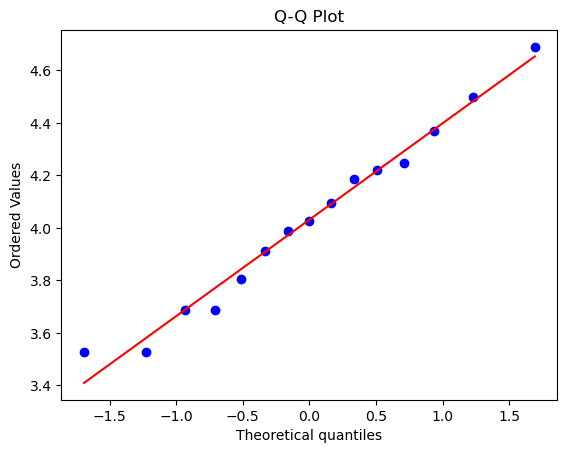

In [160]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df["MATH_log"], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()